## Wine Quality Prediction (LogisticRegression, XGBClassifier, SVC) in Scikit-Learn

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading Dataset

In [2]:
url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/54-Wine%20Quality%20Prediction/winequalityN.csv"

In [3]:
df = pd.read_csv(url)
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [4]:
df.shape

(6497, 13)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6487.0,7.216579,1.296750,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6489.0,0.339691,0.164649,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6494.0,0.318722,0.145265,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6495.0,5.444326,4.758125,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6495.0,0.056042,0.035036,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6488.0,3.218395,0.160748,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6493.0,0.531215,0.148814,0.22000,0.43000,0.51000,0.60000,2.00000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [8]:
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [9]:
for col in df.columns:
    if df[col].isnull().sum() !=0:
        df[col] = df[col].fillna(df[col].mean())

df.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


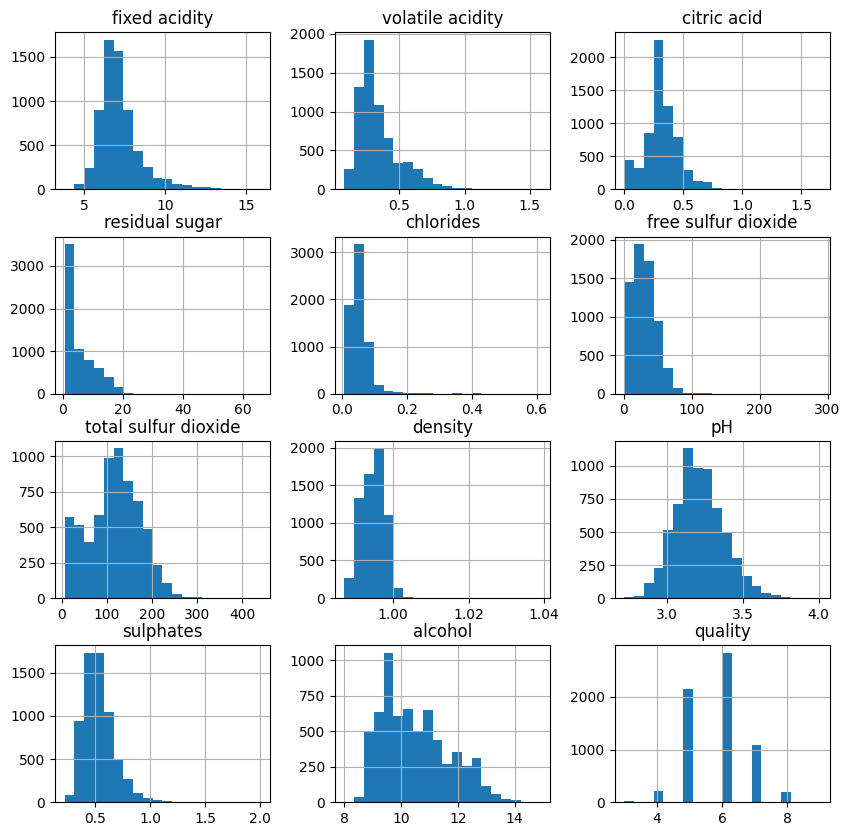

In [10]:
df.hist(bins=20, figsize=(10, 10))
plt.show()

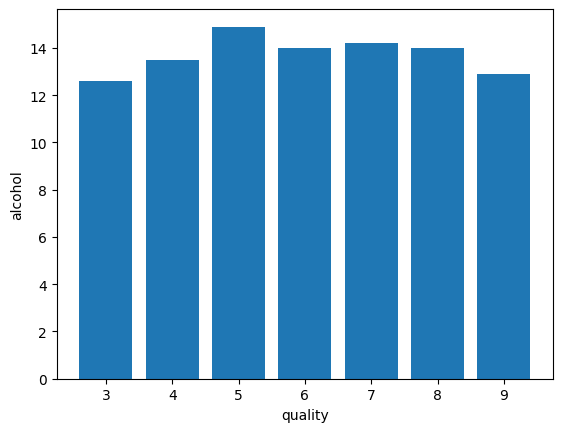

In [11]:
plt.bar(df['quality'], df['alcohol'])
plt.xlabel('quality')
plt.ylabel('alcohol')
plt.show()

In [12]:
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, replace non-convertibles with NaN
        except:
            pass  # Skip columns that cannot be converted

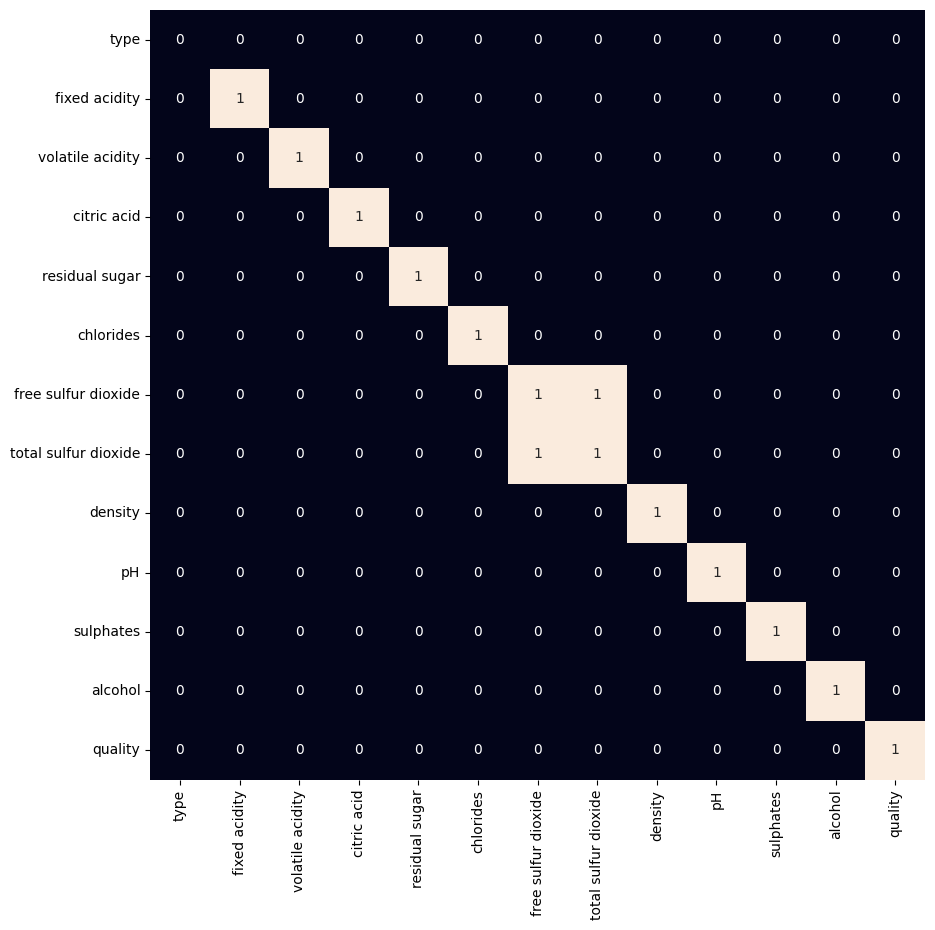

In [14]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr() > 0.7, annot=True, cbar=False)
plt.show()

In [15]:
df = df.drop('total sulfur dioxide', axis=1)

In [16]:
df['best quality'] = [1 if x > 5 else 0 for x in df.quality]

In [17]:
df.replace({'white': 1, 'red': 0}, inplace=True)

2. Feature Selection

In [18]:
X = df.drop(['quality', 'best quality'], axis=1)
y = df['best quality']

3. Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['type']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['type']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


4. Feature Scaling

In [22]:
from sklearn.preprocessing import MinMaxScaler

norm = MinMaxScaler()
X_train = norm.fit_transform(X_train)
X_test = norm.transform(X_test)

### 4. Build and Fit the Models

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf')]

train_accu =[]
test_accu = []

for i in range(3):
    models[i].fit(X_train, y_train)

    print(f'{models[i]} : ')
    train_accuracy = models[i].score(X_train, y_train)
    train_accu.append(train_accuracy)
    test_accuracy = models[i].score(X_test, y_test)
    test_accu.append(test_accuracy)
    print('Training Accuracy : ', train_accuracy)
    print('Validation Accuracy : ', test_accuracy)
    print()

LogisticRegression() : 
Training Accuracy :  0.7360015393496248
Validation Accuracy :  0.7384615384615385

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  0.9784491052530306
Validation Accuracy :  0.8376923076923077

SVC() : 
Training Accuracy :  0.76005387723686

### 5. Make Prediction

In [30]:
for i in range(3):

    print(f'{models[i]} : ')
    y_pred = models[i].predict(X_test)
    print('Prediction:',y_pred[0], ', Actual:',y_test.iloc[0])
    print()

LogisticRegression() : 
Prediction: 1 , Actual: 1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Prediction: 1 , Actual: 1

SVC() : 
Prediction: 1 , Actual: 1



### 6. Evaluate the Models

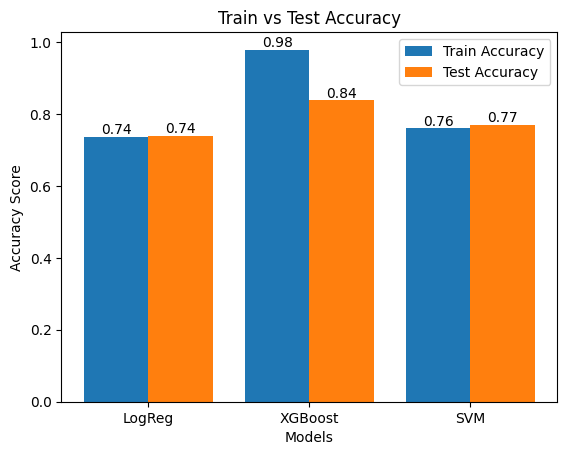

In [36]:
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}', ha='center', va='bottom')

model_names = ['LogReg', 'XGBoost', 'SVM']
x = np.arange(len(model_names))

plt.figure()
bars1 = plt.bar(x - 0.2, train_accu, width=0.4, label='Train Accuracy')
bars2 = plt.bar(x + 0.2, test_accu, width=0.4, label='Test Accuracy')

add_labels(bars1)
add_labels(bars2)

plt.xticks(x, model_names)
plt.xlabel('Models')
plt.ylabel('Accuracy Score')
plt.title('Train vs Test Accuracy')
plt.legend()

plt.show()

In [38]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

for model in range(3):
# predictions
    y_pred = models[model].predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7384615384615385

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.57      0.61       468
           1       0.77      0.83      0.80       832

    accuracy                           0.74      1300
   macro avg       0.72      0.70      0.71      1300
weighted avg       0.73      0.74      0.73      1300

Accuracy: 0.8376923076923077

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.78      0.78       468
           1       0.88      0.87      0.87       832

    accuracy                           0.84      1300
   macro avg       0.82      0.83      0.82      1300
weighted avg       0.84      0.84      0.84      1300

Accuracy: 0.7692307692307693

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.61      0.65       468
           1       0.80      0.86      0.83       832

    accuracy        

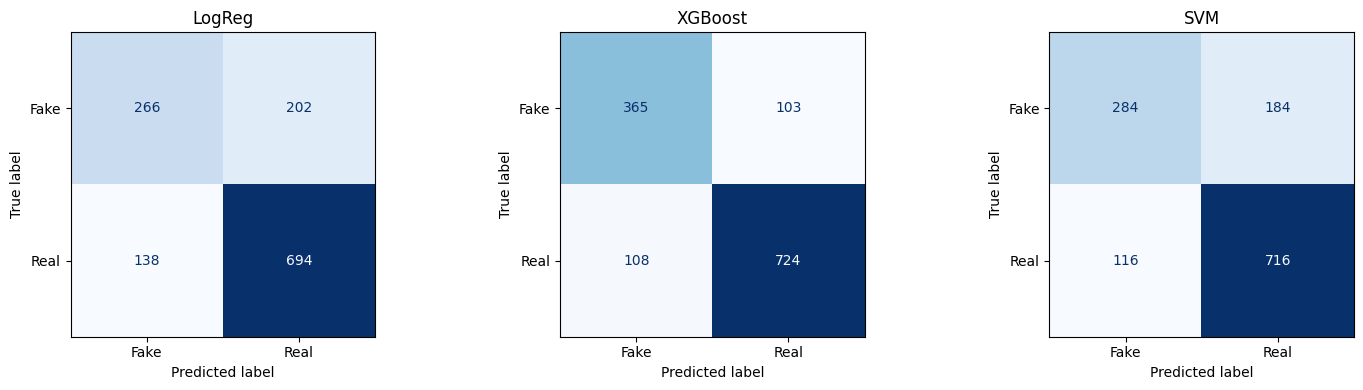

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model_names = ['LogReg', 'XGBoost', 'SVM']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    model = models[i]
    
    # predictions
    y_pred = model.predict(X_test)
    
    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Fake', 'Real']
    )
    
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(model_names[i])

plt.tight_layout()
plt.show()